In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_excel('/ApexPlanet_DataAnalytics_Dataset.xlsx')
df

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,city,product,Age_Group,Revenue_Per_Unit
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,Bengaluru,Rice,Adult,2829.77
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,Bengaluru,Book,Senior,27906.16
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,Bengaluru,Book,Senior,37491.06
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,Kolkata,Mobile,Senior,28541.36
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,Bengaluru,Rice,Middle,14036.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,ORD100997,2025-11-07,CUST6410,Customer_301,61.0,Male,Gaya,Laptop,Electronics,9,35405.54,318649.86,Gaya,Laptop,Senior,35405.54
996,ORD100998,2025-09-03,CUST7618,Customer_154,25.0,Male,Gaya,Shoes,Fashion,5,18454.65,92273.25,Gaya,Shoes,Young,18454.65
997,ORD100999,2025-09-30,CUST9544,Customer_140,62.0,Female,Hyderabad,Laptop,Electronics,9,12971.59,116744.31,Hyderabad,Laptop,Senior,12971.59
998,ORD101000,2025-02-21,CUST9501,Customer_241,NaN,Male,Delhi,Mobile,Electronics,9,2879.01,25911.09,Delhi,Mobile,NaN,2879.01


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1000 non-null   object 
 1   Order_Date        1000 non-null   object 
 2   Customer_ID       1000 non-null   object 
 3   Customer_Name     1000 non-null   object 
 4   Age               980 non-null    float64
 5   Gender            1000 non-null   object 
 6   City              987 non-null    object 
 7   Product           1000 non-null   object 
 8   Category          1000 non-null   object 
 9   Quantity          1000 non-null   int64  
 10  Unit_Price        1000 non-null   float64
 11  Total_Sales       1000 non-null   float64
 12  city              987 non-null    object 
 13  product           1000 non-null   object 
 14  Age_Group         980 non-null    object 
 15  Revenue_Per_Unit  1000 non-null   float64
dtypes: float64(4), int64(1), object(11)
memory 

In [ ]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales,Revenue_Per_Unit
count,980.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650,25486.783410
std,13.822597,2.838632,14179.402361,114100.051546,14179.402361
min,18.000000,1.000000,145.780000,437.340000,145.780000
25%,30.000000,3.000000,13895.722500,47066.632500,13895.722500
50%,41.000000,5.000000,25398.740000,108594.025000,25398.740000
75%,54.000000,8.000000,37512.382500,203722.882500,37512.382500
max,65.000000,10.000000,49997.530000,493677.500000,49997.530000


In [ ]:
df.shape

(1000, 16)

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,20
Gender,0
City,13
Product,0
Category,0
Quantity,0


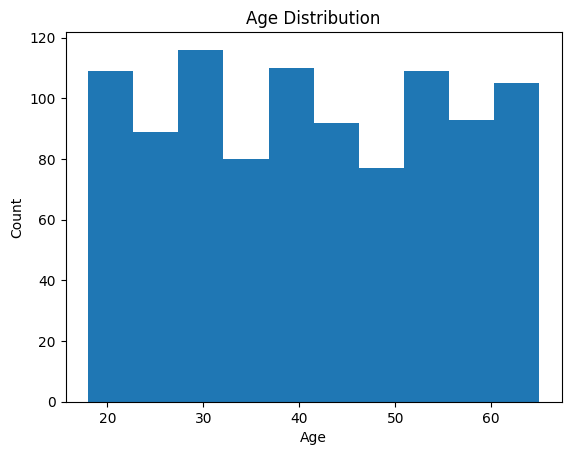

In [ ]:
#Age Distribution using histogram
plt.hist(df["Age"])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

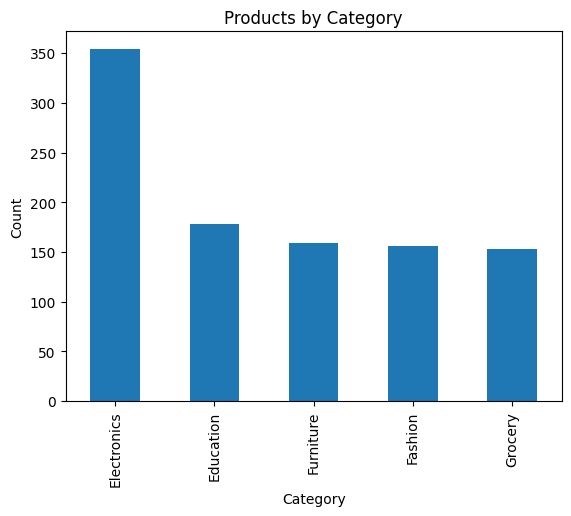

In [ ]:
#Bar Chart using Category
df["Category"].value_counts().plot(kind="bar")
plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [ ]:
#Top 5 Products by revenue
top5 = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False).head()

print(top5)

Product
Laptop    25443008.51
Mobile    25335573.19
Book      25031689.40
Rice      22231711.28
Chair     21521561.48
Name: Total_Sales, dtype: float64


In [ ]:
#Monthly sale trend
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Month"] = df["Order_Date"].dt.month

monthly = df.groupby("Month")["Total_Sales"].sum()

print(monthly)

Month
1     10905580.72
2     11511181.46
3     13059899.94
4     12222700.17
5     10984689.25
6     12912332.64
7     11746226.80
8      9448471.22
9      9179896.29
10    12500936.50
11    12627620.22
12    12299904.44
Name: Total_Sales, dtype: float64


In [ ]:
#Correlation
df.corr(numeric_only=True)

,Age,Quantity,Unit_Price,Total_Sales,Revenue_Per_Unit,Month
Age,1.000000,-0.027628,-0.012214,0.001479,-0.012214,0.015817
Quantity,-0.027628,1.000000,0.021855,0.646641,0.021855,0.052779
Unit_Price,-0.012214,0.021855,1.000000,0.686303,1.000000,-0.033452
Total_Sales,0.001479,0.646641,0.686303,1.000000,0.686303,-0.005685
Revenue_Per_Unit,-0.012214,0.021855,1.000000,0.686303,1.000000,-0.033452
Month,0.015817,0.052779,-0.033452,-0.005685,-0.033452,1.000000


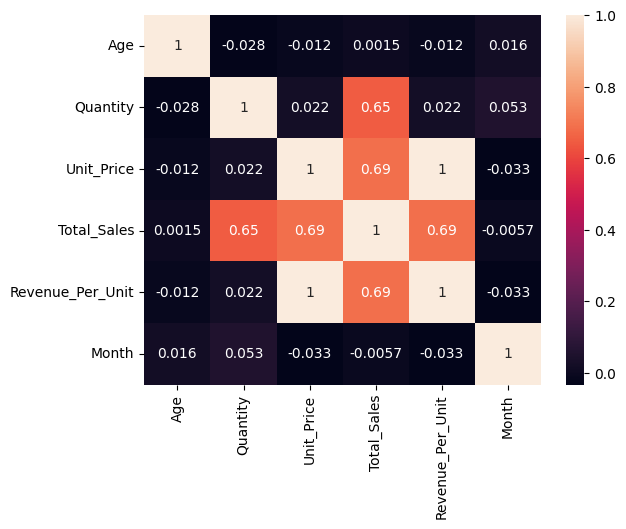

In [ ]:
#Heatmap
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

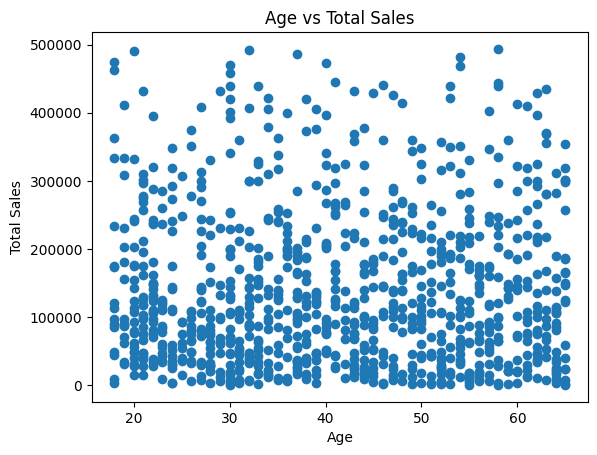

In [ ]:
#scatter plot
plt.scatter(df["Age"], df["Total_Sales"])
plt.title("Age vs Total Sales")
plt.xlabel("Age")
plt.ylabel("Total Sales")
plt.show()

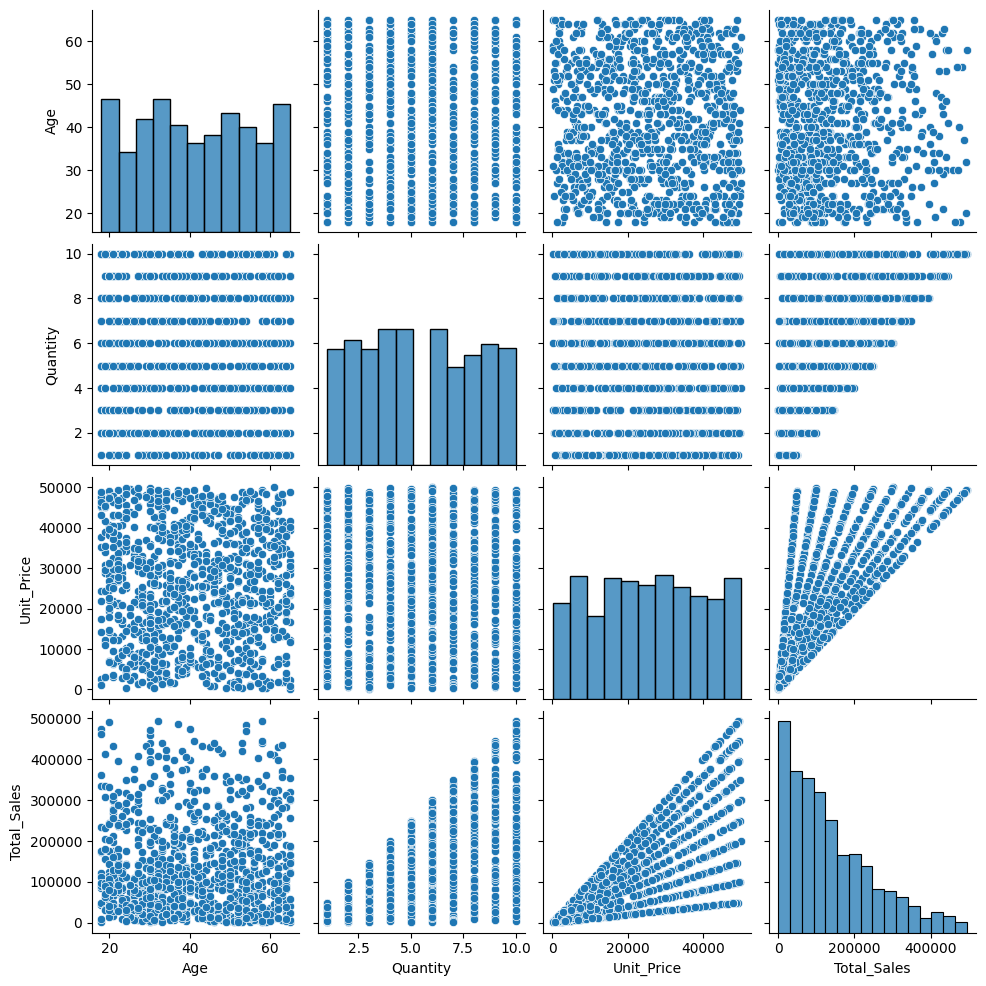

In [ ]:
#pair plot
sns.pairplot(df[["Age","Quantity","Unit_Price","Total_Sales"]])

plt.show()

In [ ]:
#BUSINESS QUESTIONS
#Top 5 Products
df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False).head()

,Total_Sales
Product,
Laptop,25443008.51
Mobile,25335573.19
Book,25031689.40
Rice,22231711.28
Chair,21521561.48


In [ ]:
#Highest Sales City
df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)

,Total_Sales
City,
Patna,19285966.89
Kolkata,18884349.57
Bengaluru,18773574.32
Mumbai,18757050.17
Hyderabad,17166766.87
Delhi,16097079.00
Pune,14513175.90
Gaya,14380859.39


In [ ]:
#Highest Selling Category
df.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

,Quantity
Category,
Electronics,1978
Education,977
Furniture,855
Grocery,826
Fashion,799


In [ ]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Month"] = df["Order_Date"].dt.month_name()

revenue = df["Total_Sales"].sum()
avg_order = df["Total_Sales"].mean()
top_product = df.groupby("Product")["Total_Sales"].sum().idxmax()
top_city = df.groupby("City")["Total_Sales"].sum().idxmax()

category_sales = df.groupby("Category")["Total_Sales"].sum()
city_sales = df.groupby("City")["Total_Sales"].sum()
product_sales = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False).head(5)
gender_sales = df.groupby("Gender")["Total_Sales"].sum()
monthly_sales = df.groupby("Month")["Total_Sales"].sum()
corr = df[["Age","Quantity","Unit_Price","Total_Sales"]].corr()

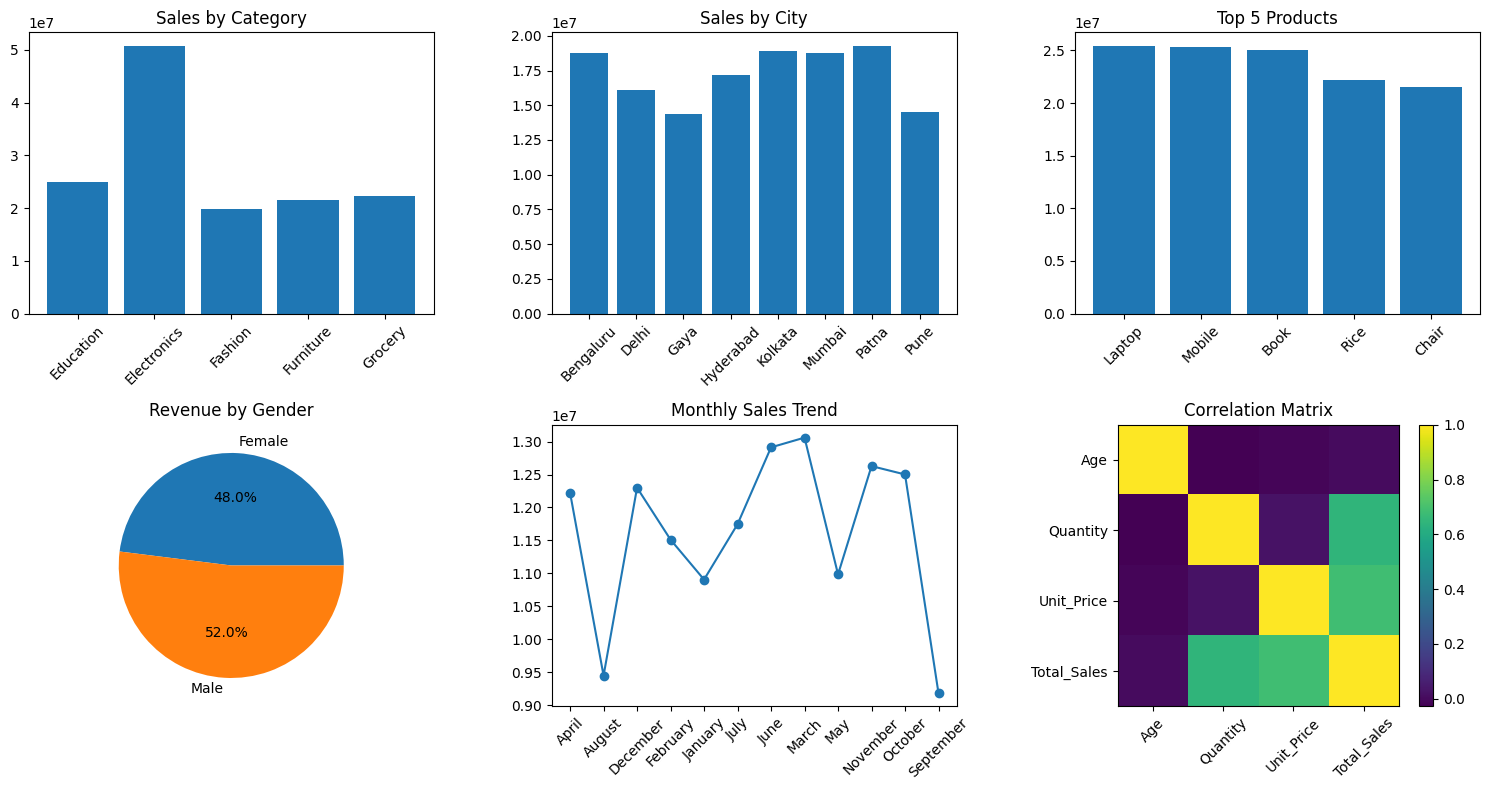

In [ ]:
fig, ax = plt.subplots(2,3, figsize=(15,8))

# Sales by Category
ax[0,0].bar(category_sales.index, category_sales.values)
ax[0,0].set_title("Sales by Category")
ax[0,0].tick_params(axis='x', rotation=45)

# Sales by City
ax[0,1].bar(city_sales.index, city_sales.values)
ax[0,1].set_title("Sales by City")
ax[0,1].tick_params(axis='x', rotation=45)

# Top Products
ax[0,2].bar(product_sales.index, product_sales.values)
ax[0,2].set_title("Top 5 Products")
ax[0,2].tick_params(axis='x', rotation=45)

# Revenue by Gender
ax[1,0].pie(gender_sales.values,
            labels=gender_sales.index,
            autopct="%1.1f%%")
ax[1,0].set_title("Revenue by Gender")

# Monthly Sales Trend
ax[1,1].plot(monthly_sales.index, monthly_sales.values, marker="o")
ax[1,1].set_title("Monthly Sales Trend")
ax[1,1].tick_params(axis='x', rotation=45)

# Correlation Matrix
img = ax[1,2].imshow(corr)
ax[1,2].set_xticks(range(len(corr.columns)))
ax[1,2].set_xticklabels(corr.columns, rotation=45)
ax[1,2].set_yticks(range(len(corr.columns)))
ax[1,2].set_yticklabels(corr.columns)
ax[1,2].set_title("Correlation Matrix")
plt.colorbar(img, ax=ax[1,2])

plt.tight_layout()
plt.show()

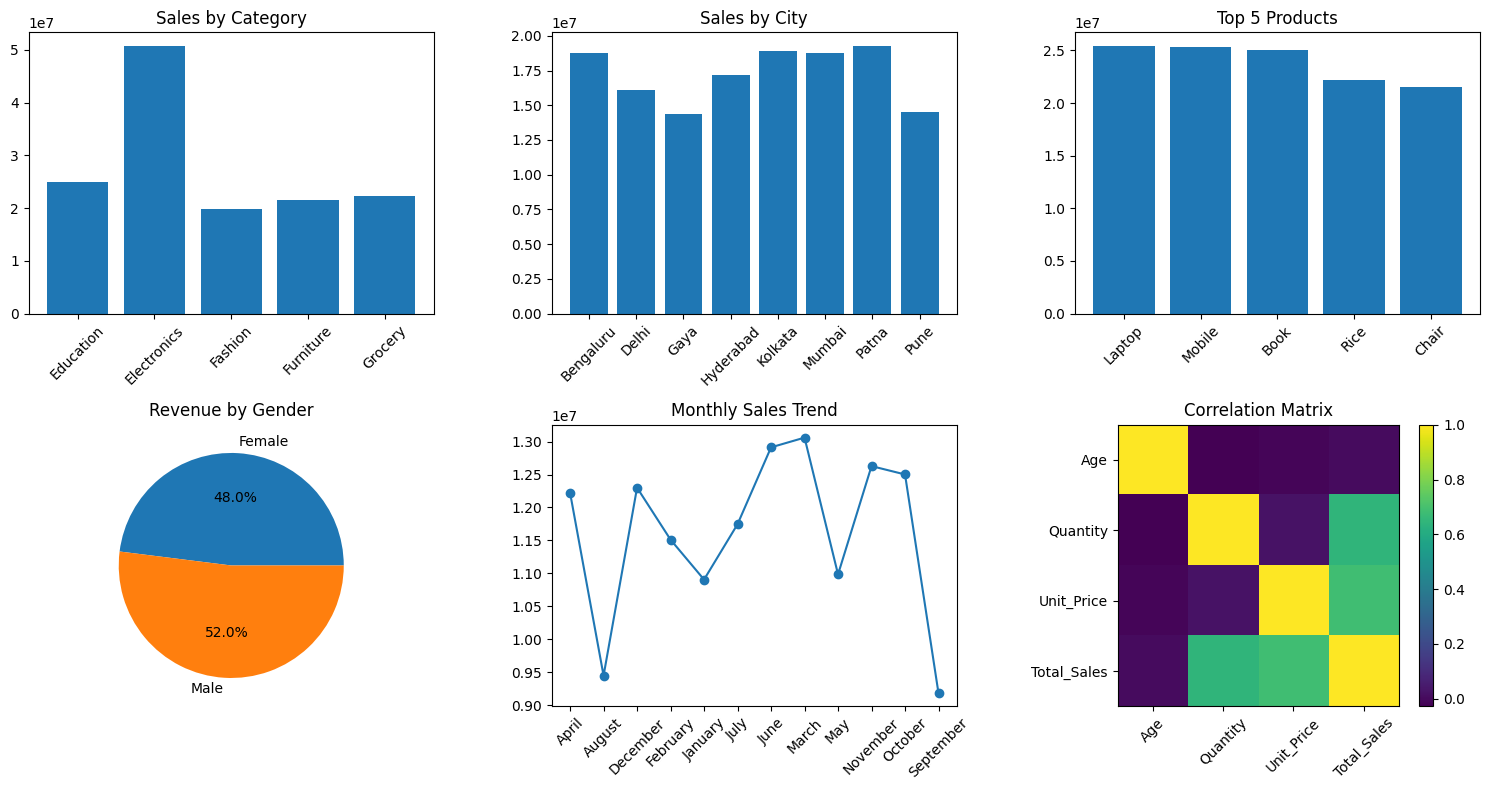

In [ ]:
fig, ax = plt.subplots(2,3, figsize=(15,8))

# Sales by Category
ax[0,0].bar(category_sales.index, category_sales.values)
ax[0,0].set_title("Sales by Category")
ax[0,0].tick_params(axis='x', rotation=45)

# Sales by City
ax[0,1].bar(city_sales.index, city_sales.values)
ax[0,1].set_title("Sales by City")
ax[0,1].tick_params(axis='x', rotation=45)

# Top Products
ax[0,2].bar(product_sales.index, product_sales.values)
ax[0,2].set_title("Top 5 Products")
ax[0,2].tick_params(axis='x', rotation=45)

# Revenue by Gender
ax[1,0].pie(gender_sales.values,
            labels=gender_sales.index,
            autopct="%1.1f%%")
ax[1,0].set_title("Revenue by Gender")

# Monthly Sales Trend
ax[1,1].plot(monthly_sales.index, monthly_sales.values, marker="o")
ax[1,1].set_title("Monthly Sales Trend")
ax[1,1].tick_params(axis='x', rotation=45)

# Correlation Matrix
img = ax[1,2].imshow(corr)
ax[1,2].set_xticks(range(len(corr.columns)))
ax[1,2].set_xticklabels(corr.columns, rotation=45)
ax[1,2].set_yticks(range(len(corr.columns)))
ax[1,2].set_yticklabels(corr.columns)
ax[1,2].set_title("Correlation Matrix")
plt.colorbar(img, ax=ax[1,2])

plt.tight_layout()
plt.show()

In [ ]:
#KPI values
print("Total Revenue :", revenue)
print("Average Order Value :", round(avg_order,2))
print("Top Product :", top_product)
print("Top City :", top_city)

Total Revenue : 139399439.65
Average Order Value : 139399.44
Top Product : Laptop
Top City : Patna
